In [1]:
import pandas as pd
import numpy as np

In [2]:
x=np.array([50, 60, 70, 80, 90] )
y=np.array([150, 180, 210, 240, 270] ) #house price in thousands

In [3]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            
            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)
            
            d_theta_0 = (-2 / n) * np.sum(y - y_pred)
            d_theta_1 = (-2 / n) * np.sum((y - y_pred) * X)
            
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

In [4]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)

model.fit(x, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)

theta_0: -1.0055957901462392e+95
theta_1: -7.326427288635144e+96


<mark>What do theta_0 and theta_1 represent in the regression equation?</mark>

-Theta 0: Represents the base value or the expected output when the input feature 

-Theta 1: Represents the rate of change (the slope of the line)

In [5]:
pred_70 = model.predict(70)

print("Predicted price for 70 m^2:", pred_70)

Predicted price for 70 m^2: -5.129504697834747e+98


Experimentation

In [6]:
model = LinearRegressionGD(learning_rate=0.00001, n_iters=1000)

model.fit(x, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)

pred_70 = model.predict(70)
print("Predicted price for 70 m^2:", pred_70)

theta_0: 0.04113676052353117
theta_1: 2.9994353734559427
Predicted price for 70 m^2: 210.00161290243952


In [11]:
# 1. Very Large Learning Rate
model_large = LinearRegressionGD(learning_rate=0.01, n_iters=100)
model_large.fit(x, y)
print("Large LR - Final SSE:", model_large.sse_history[-1])

# 2. Very Small Learning Rate
model_small = LinearRegressionGD(learning_rate=0.0000001, n_iters=100)
model_small.fit(x, y)
print("Small LR - Final SSE:", model_small.sse_history[-1])

Large LR - Final SSE: inf
Small LR - Final SSE: 187504.31789687806


C:\Users\Maydoum\AppData\Local\Temp\ipykernel_12388\2351586211.py:14: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)


<mark>Q: What happens if the learning rate is too large</mark>

-If the learning rate is too large, the algorithm takes huge steps that overshoot the minimum loss (Divergence / Exploding Gradient). This causes the loss (SSE) to become extremely large or NaN/Infinity instead of converging.  

Visualization

Text(0, 0.5, 'SSE')

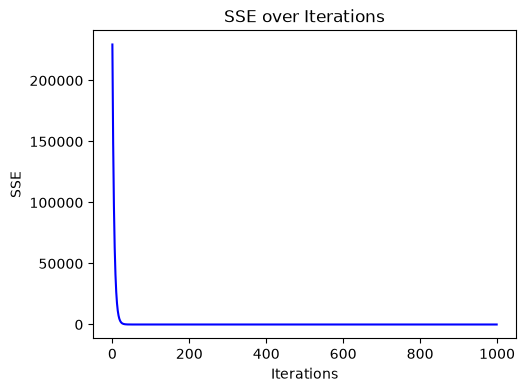

In [8]:
import matplotlib.pyplot as plt

# 1. Plot SSE over iterations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.sse_history, color='blue')
plt.title('SSE over Iterations')
plt.xlabel('Iterations')
plt.ylabel('SSE')

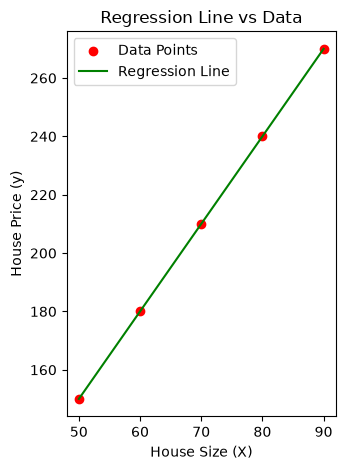

In [10]:
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='red', label='Data Points')
plt.plot(x, model.predict(x), color='green', label='Regression Line')
plt.title('Regression Line vs Data')
plt.xlabel('House Size (X)')
plt.ylabel('House Price (y)')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

y_pred = model.predict(x)
mse_val = calculate_mse(y, y_pred)
print("MSE:", mse_val)

MSE: 6.636208113002675e-05


In [13]:
# 1. Standard/Min-Max Normalization for X
X_norm = (x - x.min()) / (x.max() - x.min())

# 2. Train model with normalized X using a larger learning rate (0.1)
model_norm = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_norm.fit(X_norm, y)

print("Normalized Theta 0:", model_norm.theta_0)
print("Normalized Theta 1:", model_norm.theta_1)
print("Normalized Final SSE:", model_norm.sse_history[-1])

Normalized Theta 0: 152.1646175745174
Normalized Theta 1: 116.0944938463516
Normalized Final SSE: 10.151073814058506
